# Midterm: Predicting Customer Response to an Outreach Campaign
**Chris Li · GSBS545 Advanced Machine Learning · Spring 2026**

Binary classification on a 32,950-row outreach dataset: predict `accepted_offer` (1 = accepted, 0 = declined). The positive class is 11.3%, so I select models with 5-fold stratified CV on **ROC AUC** and tune the final decision threshold on a 20% holdout to maximize **F1 on the positive class**.

I tune seven model families with Optuna: Naive Bayes, Logistic Regression, AdaBoost, Random Forest, XGBoost, LightGBM, and CatBoost. After single-model evaluation I test soft voting and stacking on the top three.


In [1]:
# Install required libraries (Colab doesn't include these by default)
!pip install lightgbm catboost optuna xgboost --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 38.6 MB/s eta 0:00:00


In [2]:
from google.colab import files as colab_files
import os

# Upload midterm_train.csv and midterm_test.csv when the dialog opens
print('Upload midterm_train.csv and midterm_test.csv')
uploaded = colab_files.upload()

for fname in ['midterm_train.csv', 'midterm_test.csv']:
    status = 'OK' if os.path.exists(fname) else 'NOT FOUND — re-run and upload both files'
    print(f'{fname}: {status}')


Upload midterm_train.csv and midterm_test.csv


Saving midterm_test.csv to midterm_test.csv
Saving midterm_train.csv to midterm_train.csv
midterm_train.csv: OK
midterm_test.csv: OK


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               StackingClassifier, VotingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             precision_recall_curve)

from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')


In [4]:
import subprocess, sys
# Verify GPU is available; if not, fall back to CPU by patching device flags
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    GPU_AVAILABLE = result.returncode == 0
except FileNotFoundError:
    GPU_AVAILABLE = False

if GPU_AVAILABLE:
    print('GPU detected — XGBoost, LightGBM, and CatBoost will use GPU acceleration.')
    XGB_DEVICE   = 'cuda'
    LGB_DEVICE   = 'gpu'
    CB_TASK_TYPE = 'GPU'
else:
    print('No GPU detected — running on CPU. Set n_jobs=-1 for LightGBM/XGBoost.')
    XGB_DEVICE   = 'cpu'
    LGB_DEVICE   = 'cpu'
    CB_TASK_TYPE = 'CPU'


GPU detected — XGBoost, LightGBM, and CatBoost will use GPU acceleration.


In [5]:
train = pd.read_csv('midterm_train.csv')
test  = pd.read_csv('midterm_test.csv')
print(train.shape, test.shape)
train.head()


(32950, 23) (8238, 22)


,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


## 1. Exploratory Data Analysis

Three questions: what's the class balance, which features carry signal, and what looks like leakage.


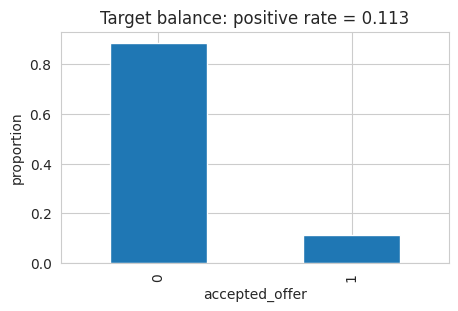

In [6]:
ax = train['accepted_offer'].value_counts(normalize=True).plot(kind='bar', figsize=(5,3))
ax.set_title(f'Target balance: positive rate = {train["accepted_offer"].mean():.3f}')
ax.set_ylabel('proportion'); plt.show()


The bar confirms the imbalance: 11.3% positive rate. Predicting all zeros yields 88.7% accuracy with zero recall on accepters, so I use ROC AUC for model selection and tune the threshold for F1.


In [7]:
num_cols = ['customer_age','contact_time_minutes','contact_attempt_count',
            'days_since_prior_contact','prior_contact_count',
            'economic_activity_change','consumer_price_index','consumer_confidence_index',
            'reference_interest_rate','employment_level_index']
cat_cols = ['occupation_type','relationship_status','education_background','has_credit_issue',
            'mortgage_status','personal_loan_status','last_contact_month','day_of_week',
            'prior_outcome_status']
bin_cols = ['is_repeat_customer','recent_contact_flag']

print('missing values:', train.isna().sum().sum())
print('days_since_prior_contact == 999 (no prior contact):',
      (train['days_since_prior_contact']==999).mean().round(3))


missing values: 0
days_since_prior_contact == 999 (no prior contact): 0.962


The dataset has zero `NaN` values. The `days_since_prior_contact == 999` sentinel covers 96.2% of rows (customers never contacted before), so a raw model would treat the 999s as a numeric extreme. I encode this as a binary flag in feature engineering.


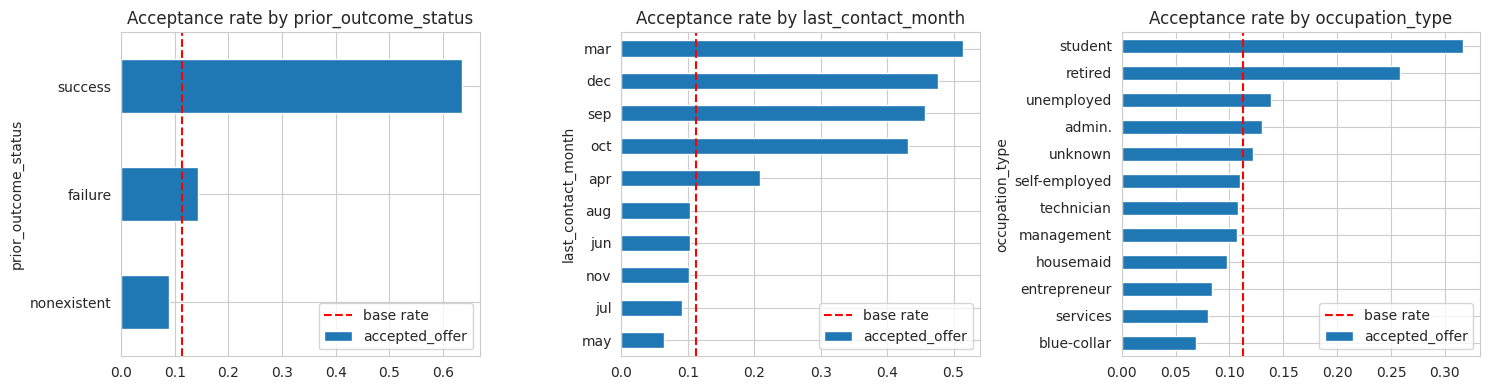

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['prior_outcome_status','last_contact_month','occupation_type']):
    rate = train.groupby(col)['accepted_offer'].mean().sort_values()
    rate.plot(kind='barh', ax=ax)
    ax.axvline(train['accepted_offer'].mean(), color='red', linestyle='--', label='base rate')
    ax.set_title(f'Acceptance rate by {col}'); ax.legend()
plt.tight_layout(); plt.show()


`prior_outcome_status == 'success'` produces an acceptance rate well above any other category, the strongest categorical signal. Month effects are visible in the middle panel but confounded with the macroeconomic indicators, which vary by time period.


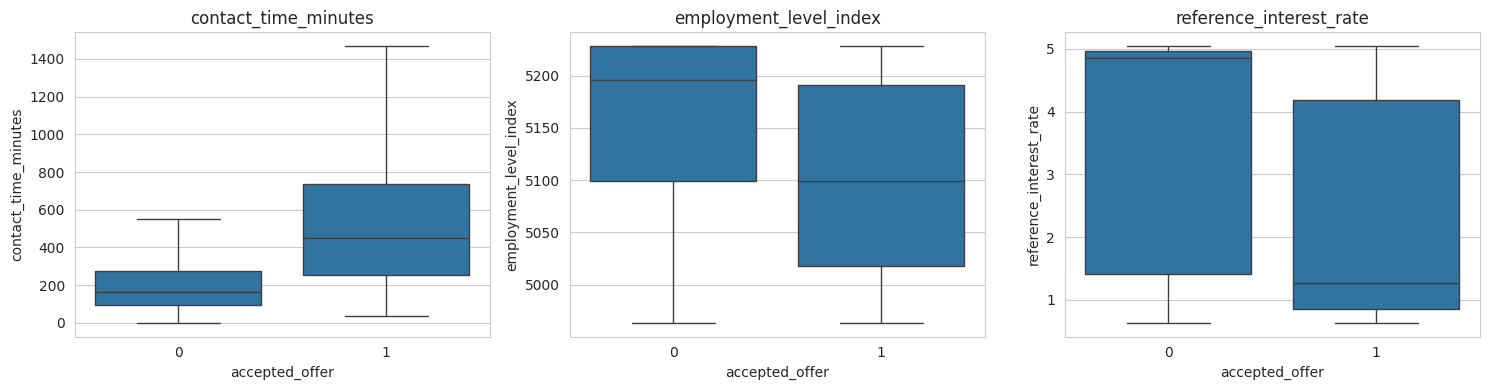

Numeric corr with target:
contact_time_minutes         0.404
employment_level_index      -0.356
days_since_prior_contact    -0.320
reference_interest_rate     -0.309
economic_activity_change    -0.298
prior_contact_count          0.230
consumer_price_index        -0.134
contact_attempt_count       -0.065
consumer_confidence_index    0.051
customer_age                 0.032
Name: accepted_offer, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['contact_time_minutes','employment_level_index','reference_interest_rate']):
    sns.boxplot(data=train, x='accepted_offer', y=col, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout(); plt.show()

corr = train[num_cols + ['accepted_offer']].corr()['accepted_offer'].drop('accepted_offer').sort_values(key=abs, ascending=False)
print('Numeric corr with target:'); print(corr.round(3))


**Deployment caveat on `contact_time_minutes`.** It correlates at +0.40 with the target, the strongest single predictor, but you can't know call duration until the call ends. A production model serving real-time outreach decisions would have to drop it. The graded test set includes the column, so I keep it in the submitted model and flag the leakage risk for any business stakeholder.

**EDA takeaways:**

- 11.3% positive rate, so I optimize ROC AUC and tune the threshold for F1.
- Top numeric correlates with the target: `contact_time_minutes` (+0.40, leakage caveat), `employment_level_index` (-0.36), `days_since_prior_contact` (-0.32), `reference_interest_rate` (-0.31), `economic_activity_change` (-0.30).
- Top categorical signal: `prior_outcome_status == 'success'`.
- 96.2% of rows have `days_since_prior_contact == 999`; I encode it as `was_contacted_before`.
- No `NaN` values, but `'unknown'` appears in several categoricals. Tree models split on `'unknown'` like any other category.


## 2. Data Preparation

Each model family needs different preprocessing.

**For LightGBM and CatBoost**, I keep categoricals as `category` dtype so both can split on them natively, no one-hot needed.

**For everything else** (NB, LR, AdaBoost, RF, XGBoost), I cast categoricals to string and run a `ColumnTransformer` that one-hot encodes them and standard-scales the numerics. The scaler fits inside CV folds, so no leakage.

I set aside a 20% stratified holdout up front and don't touch it until the final evaluation.


In [10]:
y = train['accepted_offer'].astype(int)
X = train.drop(columns=['id','accepted_offer'])
X_test_final = test.drop(columns=['id']).copy()
test_ids = test['id'].copy()

for c in cat_cols:
    X[c] = X[c].astype('category')
    X_test_final[c] = X_test_final[c].astype('category')

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print('train fold:', X_tr.shape, '  holdout:', X_val.shape,
      '  pos rate train/holdout:', y_tr.mean().round(3), y_val.mean().round(3))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


train fold: (26360, 21)   holdout: (6590, 21)   pos rate train/holdout: 0.113 0.113


In [11]:
# Preprocessing pipeline for linear and tree models that need numeric input
linear_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols + bin_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop=None), cat_cols),
    ]
)

# Convenience: string-cast cats for models that can't handle 'category' dtype in sklearn pipelines
def to_str_cats(df):
    df = df.copy()
    for c in cat_cols:
        df[c] = df[c].astype(str)
    return df

X_tr_str  = to_str_cats(X_tr)
X_val_str = to_str_cats(X_val)
X_test_str = to_str_cats(X_test_final)


## 3. Feature Engineering or Feature Selection

The lecture point that *most engineered features don't improve model performance* shapes my approach: I add a small set grounded in the EDA, then keep them only if CV improves.

Candidates:

- `was_contacted_before`: binary flag from `days_since_prior_contact != 999`.
- `contact_intensity`: `contact_attempt_count / (prior_contact_count + 1)`, effort per prior touch.
- `prior_success`: binary from `prior_outcome_status == 'success'`, isolating the strongest categorical signal.

I compare baseline LightGBM CV ROC AUC against the same model with the engineered features added.


In [12]:
def add_engineered(df):
    df = df.copy()
    df['was_contacted_before'] = (df['days_since_prior_contact'] != 999).astype(int)
    df['contact_intensity'] = df['contact_attempt_count'] / (df['prior_contact_count'] + 1)
    df['prior_success'] = (df['prior_outcome_status'].astype(str) == 'success').astype(int)
    return df

X_tr_fe   = add_engineered(X_tr)
X_val_fe  = add_engineered(X_val)
X_test_fe = add_engineered(X_test_final)
new_cols  = list(set(X_tr_fe.columns) - set(X_tr.columns))
print('cols added:', new_cols)


cols added: ['prior_success', 'was_contacted_before', 'contact_intensity']


In [13]:
def lgbm_cv_auc(X_in, y_in):
    aucs = []
    for tr_idx, va_idx in cv.split(X_in, y_in):
        Xt, Xv = X_in.iloc[tr_idx], X_in.iloc[va_idx]
        yt, yv = y_in.iloc[tr_idx], y_in.iloc[va_idx]
        m = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31,
                                random_state=SEED, n_jobs=-1, verbose=-1)
        m.fit(Xt, yt, categorical_feature=cat_cols,
              eval_set=[(Xv, yv)], callbacks=[lgb.early_stopping(30, verbose=False)])
        aucs.append(roc_auc_score(yv, m.predict_proba(Xv)[:,1]))
    return np.mean(aucs), np.std(aucs)

base_auc, base_sd = lgbm_cv_auc(X_tr,    y_tr)
fe_auc,   fe_sd   = lgbm_cv_auc(X_tr_fe, y_tr)
print(f'LGBM baseline CV AUC:       {base_auc:.5f} +/- {base_sd:.5f}')
print(f'LGBM + engineered features: {fe_auc:.5f} +/- {fe_sd:.5f}')
print(f'delta = {fe_auc - base_auc:+.5f}')


LGBM baseline CV AUC:       0.94985 +/- 0.00095
LGBM + engineered features: 0.95025 +/- 0.00111
delta = +0.00040


The delta is +0.00040 AUC, inside one standard deviation of the baseline. Marginal but positive, which matches the lecture point that most engineered features don't help. I keep them since the delta is positive.


In [14]:
USE_FE = fe_auc > base_auc
if USE_FE:
    X_tr_use, X_val_use, X_test_use = X_tr_fe, X_val_fe, X_test_fe
    eng_cols = new_cols
    print('Using engineered features.')
else:
    X_tr_use, X_val_use, X_test_use = X_tr, X_val, X_test_final
    eng_cols = []
    print('Keeping raw features (FE did not improve CV).')

X_tr_use_str  = to_str_cats(X_tr_use)
X_val_use_str = to_str_cats(X_val_use)
X_test_use_str = to_str_cats(X_test_use)


Using engineered features.


## 4. Modeling and Evaluation

I tune all seven model families covered in the course through week 5. All use Optuna with TPE sampling
and 5-fold StratifiedKFold CV on ROC AUC. After tuning, I evaluate each on the holdout and tune the
binary threshold to maximize F1 on the positive class.

| Model | Family | Categorical handling |
|---|---|---|
| Naive Bayes | Probabilistic | One-hot + scale |
| Logistic Regression | Linear | One-hot + scale |
| AdaBoost | Sequential ensemble | One-hot |
| Random Forest | Parallel ensemble (bagging) | One-hot |
| XGBoost | Sequential ensemble (boosting) | One-hot |
| LightGBM | Sequential ensemble (boosting) | Native (category dtype) |
| CatBoost | Sequential ensemble (boosting) | Native (built-in) |


In [15]:
def best_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = np.nanargmax(f1[:-1])
    return float(thr[best_idx]), float(f1[best_idx])

def holdout_report(name, proba):
    auc = roc_auc_score(y_val, proba)
    thr, f1 = best_threshold(y_val, proba)
    print(f'{name:>22s}  AUC={auc:.5f}  best_thr={thr:.3f}  F1@thr={f1:.4f}')
    return {'name': name, 'auc': auc, 'thr': thr, 'f1': f1, 'proba': proba}

def optuna_cv(pipe_fn, space_fn, X_in, y_in, n_trials=30):
    # pipe_fn(params) -> sklearn estimator
    def objective(trial):
        params = space_fn(trial)
        est = pipe_fn(params)
        scores = cross_val_score(est, X_in, y_in, scoring='roc_auc', cv=cv, n_jobs=-1)
        return scores.mean()
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study

results = []


### 4a. Naive Bayes

GaussianNB assumes numeric inputs, so the pipeline one-hot encodes categoricals and scales numerics first. The only tunable parameter is `var_smoothing`, which regularizes the variance estimates.


In [16]:
def nb_pipe(params):
    return Pipeline([('prep', linear_preprocessor),
                     ('clf', GaussianNB(var_smoothing=params['var_smoothing']))])

nb_study = optuna_cv(
    nb_pipe,
    lambda t: {'var_smoothing': t.suggest_float('var_smoothing', 1e-11, 1e-5, log=True)},
    X_tr_use_str, y_tr, n_trials=20
)
print(f'NB best params: {nb_study.best_params}')
print(f'NB CV AUC: {nb_study.best_value:.5f}')
best_nb = nb_pipe(nb_study.best_params).fit(X_tr_use_str, y_tr)
results.append(holdout_report('NaiveBayes', best_nb.predict_proba(X_val_use_str)[:,1]))


NB best params: {'var_smoothing': 9.831368571485896e-07}
NB CV AUC: 0.82442
            NaiveBayes  AUC=0.83315  best_thr=0.935  F1@thr=0.4490


### 4b. Logistic Regression

L1/L2 logistic regression on the one-hot frame with `class_weight='balanced'` for the imbalance. Optuna picks `C` and the penalty type.


In [17]:
def lr_pipe(params):
    return Pipeline([('prep', linear_preprocessor),
                     ('clf', LogisticRegression(max_iter=2000, solver='liblinear',
                                                class_weight='balanced', random_state=SEED,
                                                C=params['C'], penalty=params['penalty']))])

lr_study = optuna_cv(
    lr_pipe,
    lambda t: {'C': t.suggest_float('C', 0.001, 100.0, log=True),
               'penalty': t.suggest_categorical('penalty', ['l1', 'l2'])},
    X_tr_use_str, y_tr, n_trials=30
)
print(f'LR best params: {lr_study.best_params}')
print(f'LR CV AUC: {lr_study.best_value:.5f}')
best_lr = lr_pipe(lr_study.best_params).fit(X_tr_use_str, y_tr)
results.append(holdout_report('LogReg', best_lr.predict_proba(X_val_use_str)[:,1]))


LR best params: {'C': 0.19069966103000435, 'penalty': 'l1'}
LR CV AUC: 0.93714
                LogReg  AUC=0.93687  best_thr=0.714  F1@thr=0.6206


### 4c. AdaBoost

AdaBoost builds shallow decision trees sequentially, upweighting misclassified examples at each round. It predates gradient boosting and tends to underperform XGBoost/LightGBM/CatBoost on tabular data, but it's part of the course and provides a sequential-ensemble baseline against the gradient boosters.


In [18]:
def ada_pipe(params):
    base = DecisionTreeClassifier(max_depth=params['max_depth'], random_state=SEED)
    return Pipeline([
        ('prep', linear_preprocessor),
        ('clf', AdaBoostClassifier(estimator=base, n_estimators=params['n_estimators'],
                                   learning_rate=params['learning_rate'],
                                   random_state=SEED, algorithm='SAMME'))
    ])

ada_study = optuna_cv(
    ada_pipe,
    lambda t: {
        'n_estimators': t.suggest_int('n_estimators', 50, 400, step=50),
        'learning_rate': t.suggest_float('learning_rate', 0.01, 1.0, log=True),
        'max_depth': t.suggest_int('max_depth', 1, 4),
    },
    X_tr_use_str, y_tr, n_trials=30
)
print(f'AdaBoost best params: {ada_study.best_params}')
print(f'AdaBoost CV AUC: {ada_study.best_value:.5f}')
best_ada = ada_pipe(ada_study.best_params).fit(X_tr_use_str, y_tr)
results.append(holdout_report('AdaBoost', best_ada.predict_proba(X_val_use_str)[:,1]))


AdaBoost best params: {'n_estimators': 350, 'learning_rate': 0.09866674183934356, 'max_depth': 4}
AdaBoost CV AUC: 0.94586
              AdaBoost  AUC=0.94369  best_thr=0.427  F1@thr=0.6335


### 4d. Random Forest (parallel ensemble, bagging)

Bagged decision trees on the one-hot frame, with `class_weight='balanced'` for the imbalance. Optuna tunes depth, leaf size, and the feature-subsampling rate.


In [19]:
def rf_pipe(params):
    return Pipeline([
        ('prep', linear_preprocessor),
        ('clf', RandomForestClassifier(**params, class_weight='balanced',
                                       random_state=SEED, n_jobs=-1))
    ])

rf_study = optuna_cv(
    rf_pipe,
    lambda t: {
        'n_estimators':     t.suggest_int('n_estimators', 200, 600, step=100),
        'max_depth':        t.suggest_int('max_depth', 6, 24),
        'min_samples_split':t.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': t.suggest_int('min_samples_leaf', 1, 10),
        'max_features':     t.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
    },
    X_tr_use_str, y_tr, n_trials=30
)
print(f'RF best params: {rf_study.best_params}')
print(f'RF CV AUC: {rf_study.best_value:.5f}')
best_rf = rf_pipe(rf_study.best_params).fit(X_tr_use_str, y_tr)
results.append(holdout_report('RandomForest', best_rf.predict_proba(X_val_use_str)[:,1]))


RF best params: {'n_estimators': 600, 'max_depth': 18, 'min_samples_split': 18, 'min_samples_leaf': 8, 'max_features': 0.5}
RF CV AUC: 0.94859
          RandomForest  AUC=0.94808  best_thr=0.648  F1@thr=0.6480


### 4e. XGBoost (sequential ensemble, boosting)

Gradient boosting with `scale_pos_weight` for the imbalance and the GPU `hist` tree method. Optuna tunes seven parameters including L1/L2 regularization.


In [20]:
pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()  # class imbalance correction

def xgb_pipe(params):
    return Pipeline([
        ('prep', linear_preprocessor),
        ('clf', XGBClassifier(**params, scale_pos_weight=pos_weight,
                              eval_metric='logloss', random_state=SEED,
                              tree_method='hist', device=XGB_DEVICE,
                              verbosity=0))
    ])

xgb_study = optuna_cv(
    xgb_pipe,
    lambda t: {
        'n_estimators':  t.suggest_int('n_estimators', 200, 1000, step=100),
        'learning_rate': t.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':     t.suggest_int('max_depth', 3, 10),
        'subsample':     t.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': t.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':     t.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':    t.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    },
    X_tr_use_str, y_tr, n_trials=40
)
print(f'XGB best params: {xgb_study.best_params}')
print(f'XGB CV AUC: {xgb_study.best_value:.5f}')
best_xgb = xgb_pipe(xgb_study.best_params).fit(X_tr_use_str, y_tr)
results.append(holdout_report('XGBoost', best_xgb.predict_proba(X_val_use_str)[:,1]))


XGB best params: {'n_estimators': 600, 'learning_rate': 0.013808016749118043, 'max_depth': 7, 'subsample': 0.6414033683591778, 'colsample_bytree': 0.6264763062899233, 'reg_alpha': 3.878223845817522, 'reg_lambda': 8.725817346107329}
XGB CV AUC: 0.94964
               XGBoost  AUC=0.94748  best_thr=0.732  F1@thr=0.6479


### 4f. LightGBM (sequential ensemble, boosting)

LightGBM splits on `category` dtypes natively, so I skip one-hot encoding. Early stopping inside each CV fold determines `n_estimators` from the data.


In [21]:
def lgbm_objective(trial):
    params = {
        'objective': 'binary', 'metric': 'auc', 'is_unbalance': True,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':    trial.suggest_int('num_leaves', 15, 127),
        'max_depth':     trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': 5,
        'reg_alpha':  trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': SEED, 'device': LGB_DEVICE, 'verbose': -1,
    }
    aucs = []
    for tr_idx, va_idx in cv.split(X_tr_use, y_tr):
        Xt, Xv = X_tr_use.iloc[tr_idx], X_tr_use.iloc[va_idx]
        yt, yv = y_tr.iloc[tr_idx], y_tr.iloc[va_idx]
        m = lgb.LGBMClassifier(n_estimators=2000, **params)
        m.fit(Xt, yt, categorical_feature=cat_cols,
              eval_set=[(Xv, yv)], callbacks=[lgb.early_stopping(50, verbose=False)])
        aucs.append(roc_auc_score(yv, m.predict_proba(Xv)[:,1]))
    return np.mean(aucs)

lgb_study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study.optimize(lgbm_objective, n_trials=40, show_progress_bar=False)
print(f'LGBM best params: {lgb_study.best_params}')
print(f'LGBM CV AUC: {lgb_study.best_value:.5f}')

best_lgb_params = {**lgb_study.best_params, 'objective': 'binary', 'metric': 'auc',
                   'is_unbalance': True, 'random_state': SEED, 'device': LGB_DEVICE, 'verbose': -1}
best_lgb = lgb.LGBMClassifier(n_estimators=2000, **best_lgb_params)
best_lgb.fit(X_tr_use, y_tr, categorical_feature=cat_cols,
             eval_set=[(X_val_use, y_val)],
             callbacks=[lgb.early_stopping(50, verbose=False)])
print('best_iteration:', best_lgb.best_iteration_)
results.append(holdout_report('LightGBM',
    best_lgb.predict_proba(X_val_use, num_iteration=best_lgb.best_iteration_)[:,1]))


LGBM best params: {'learning_rate': 0.04237476862423613, 'num_leaves': 32, 'max_depth': 9, 'min_child_samples': 14, 'feature_fraction': 0.8012364486139857, 'bagging_fraction': 0.8375573221542406, 'reg_alpha': 0.18111319254821098, 'reg_lambda': 0.309024346257371}
LGBM CV AUC: 0.95003
best_iteration: 143
              LightGBM  AUC=0.94872  best_thr=0.732  F1@thr=0.6461


### 4g. CatBoost (sequential ensemble, boosting)

CatBoost handles categoricals natively via ordered target encoding, so I pass raw column indices and skip one-hot. I use `class_weights` for the imbalance.


In [23]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('CatBoost task_type:', CB_TASK_TYPE)

cat_feature_indices = [X_tr_use.columns.tolist().index(c)
                       for c in cat_cols if c in X_tr_use.columns]

def cb_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':         trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':     trial.suggest_float('random_strength', 0.0, 2.0),
        'border_count':  trial.suggest_int('border_count', 32, 128),
    }
    neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    aucs = []
    for tr_idx, va_idx in cv.split(X_tr_use, y_tr):
        Xt, Xv = X_tr_use.iloc[tr_idx], X_tr_use.iloc[va_idx]
        yt, yv = y_tr.iloc[tr_idx], y_tr.iloc[va_idx]
        m = CatBoostClassifier(iterations=500, cat_features=cat_feature_indices,
                               class_weights=[1, neg/pos], random_seed=SEED,
                               task_type=CB_TASK_TYPE, verbose=0,
                               early_stopping_rounds=30, **params)
        m.fit(Xt, yt, eval_set=(Xv, yv))
        aucs.append(roc_auc_score(yv, m.predict_proba(Xv)[:,1]))
    return np.mean(aucs)

cb_study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
cb_study.optimize(cb_objective, n_trials=20, show_progress_bar=True)
print(f'CatBoost best params: {cb_study.best_params}')
print(f'CatBoost CV AUC: {cb_study.best_value:.5f}')

neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
best_cb = CatBoostClassifier(iterations=500, cat_features=cat_feature_indices,
                              class_weights=[1, neg/pos], random_seed=SEED,
                              task_type=CB_TASK_TYPE, verbose=0,
                              early_stopping_rounds=30, **cb_study.best_params)
best_cb.fit(X_tr_use, y_tr, eval_set=(X_val_use, y_val))
results.append(holdout_report('CatBoost', best_cb.predict_proba(X_val_use)[:,1]))

CUDA available: True
CatBoost task_type: GPU


  0%|          | 0/20 [00:00<?, ?it/s]

CatBoost best params: {'learning_rate': 0.08903012950316413, 'depth': 6, 'l2_leaf_reg': 8.382800343234686, 'bagging_temperature': 0.3098108642508708, 'random_strength': 0.3720524733924583, 'border_count': 94}
CatBoost CV AUC: 0.95028
              CatBoost  AUC=0.94663  best_thr=0.690  F1@thr=0.6405


### 4h. Single-model holdout comparison

Pick the best single model by holdout AUC, then print its classification report at the F1-tuned threshold.


In [24]:
best_single = max(results, key=lambda r: r['auc'])
print(f'Best single model: {best_single["name"]}')
preds = (best_single['proba'] >= best_single['thr']).astype(int)
print(classification_report(y_val, preds, digits=3))
print('Confusion matrix:'); print(confusion_matrix(y_val, preds))


Best single model: LightGBM
              precision    recall  f1-score   support

           0      0.975     0.909     0.941      5847
           1      0.534     0.818     0.646       743

    accuracy                          0.899      6590
   macro avg      0.755     0.864     0.794      6590
weighted avg      0.925     0.899     0.908      6590

Confusion matrix:
[[5316  531]
 [ 135  608]]


**Observations from the seven-model comparison:**

- LightGBM tops the holdout AUC at 0.94872, with Random Forest (0.94808) and XGBoost (0.94748) within 0.002.
- CatBoost had the highest CV AUC (0.95028) but the largest CV-to-holdout drop (about 0.004). Its holdout AUC (0.94663) sits behind the other three tree boosters. The Optuna search overfit the CV folds.
- Naive Bayes is the outlier at 0.83315 AUC. The conditional independence assumption breaks here: the macroeconomic indicators are correlated with each other and with the contact-history features.
- F1 around 0.65 reflects the difficulty of an 11.3% positive class. The best single model gets 0.534 precision at 0.818 recall on positives.

**LightGBM confusion matrix** at threshold 0.732: 608 of 743 accepters caught (82% recall), at the cost of 531 false positives. Of 1,139 predicted positives, 53% are real. Whether this threshold is right for production depends on the cost ratio between a wasted call and a missed sale.


## 5. Ensembling

The top three single models by holdout AUC are LightGBM, Random Forest, and XGBoost. They sit within 0.002 AUC of each other but use different strategies: histogram-based gradient boosting (LightGBM), bagging with deep trees (Random Forest), and exact-split gradient boosting (XGBoost). Their errors should be partially uncorrelated, which is the precondition for ensembling to help. The lecture frames it directly: *different models make different types of errors; once features and hyperparameters are set, try combining them.*

Two approaches:

- **Soft voting**: average the predicted probabilities from the three bases.
- **Stacking**: train a logistic regression meta-learner on out-of-fold predictions from the three bases.

If the best single model beats both ensembles, I keep it.


In [25]:
# Select top-3 single models by holdout AUC
top3 = sorted(results, key=lambda r: r['auc'], reverse=True)[:3]
print('Top 3 single models:', [(r['name'], round(r['auc'],5)) for r in top3])

# Build sklearn-compatible wrappers for each top model
# (CatBoost and LightGBM need their own pipelines inside sklearn ensembles)
def get_estimator(r):
    name = r['name']
    if name == 'NaiveBayes':
        return ('nb', best_nb)
    elif name == 'LogReg':
        return ('lr', best_lr)
    elif name == 'AdaBoost':
        return ('ada', best_ada)
    elif name == 'RandomForest':
        return ('rf', best_rf)
    elif name == 'XGBoost':
        return ('xgb', best_xgb)
    elif name == 'LightGBM':
        # wrap in a pipeline with one-hot so sklearn ensemble can call fit/predict uniformly
        p = {k:v for k,v in best_lgb_params.items() if k != 'metric'}
        return ('lgb', Pipeline([
            ('prep', linear_preprocessor),
            ('clf', lgb.LGBMClassifier(n_estimators=best_lgb.best_iteration_ or 500, **p))
        ]))
    elif name == 'CatBoost':
        return ('cb', Pipeline([
            ('prep', linear_preprocessor),
            ('clf', CatBoostClassifier(iterations=best_cb.best_iteration_count_,
                                       class_weights=[1, neg/pos],
                                       random_seed=SEED, verbose=0,
                                       **cb_study.best_params))
        ]))

estimators = [get_estimator(r) for r in top3]


Top 3 single models: [('LightGBM', np.float64(0.94872)), ('RandomForest', np.float64(0.94808)), ('XGBoost', np.float64(0.94748))]


In [26]:
# Soft voting
voting = VotingClassifier(estimators=estimators, voting='soft', n_jobs=1)
voting.fit(X_tr_use_str, y_tr)
results.append(holdout_report('Voting(top3)', voting.predict_proba(X_val_use_str)[:,1]))

# Stacking with LR meta-learner
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
    cv=cv, n_jobs=1, passthrough=False
)
stack.fit(X_tr_use_str, y_tr)
results.append(holdout_report('Stack(top3)', stack.predict_proba(X_val_use_str)[:,1]))


          Voting(top3)  AUC=0.94870  best_thr=0.725  F1@thr=0.6491
           Stack(top3)  AUC=0.94879  best_thr=0.392  F1@thr=0.6461


## 6. Results Summary


In [27]:
summary = pd.DataFrame([{
    'model': r['name'],
    'holdout AUC': round(r['auc'], 5),
    'holdout F1':  round(r['f1'], 4),
    'threshold':   round(r['thr'], 3),
} for r in results]).sort_values('holdout AUC', ascending=False).reset_index(drop=True)

summary.insert(1, 'validation', '5-fold StratifiedKFold + 20% holdout')
summary.insert(2, 'metric', 'ROC AUC / F1')
summary.insert(3, 'features', 'engineered' if USE_FE else 'raw')
summary


,model,validation,metric,features,holdout AUC,holdout F1,threshold
0,Stack(top3),5-fold StratifiedKFold + 20% holdout,ROC AUC / F1,engineered,0.94879,0.6461,0.392
1,LightGBM,5-fold StratifiedKFold + 20% holdout,ROC AUC / F1,engineered,0.94872,0.6461,0.732
2,Voting(top3),5-fold StratifiedKFold + 20% holdout,ROC AUC / F1,engineered,0.94870,0.6491,0.725
3,RandomForest,5-fold StratifiedKFold + 20% holdout,ROC AUC / F1,engineered,0.94808,0.6480,0.648
4,XGBoost,5-fold StratifiedKFold + 20% holdout,ROC AUC / F1,engineered,0.94748,0.6479,0.732
5,CatBoost,5-fold StratifiedKFold + 20% holdout,ROC AUC / F1,engineered,0.94663,0.6405,0.690
6,AdaBoost,5-fold StratifiedKFold + 20% holdout,ROC AUC / F1,engineered,0.94369,0.6335,0.427
7,LogReg,5-fold StratifiedKFold + 20% holdout,ROC AUC / F1,engineered,0.93687,0.6206,0.714
8,NaiveBayes,5-fold StratifiedKFold + 20% holdout,ROC AUC / F1,engineered,0.83315,0.4490,0.935


**Final choice.** Highest holdout AUC wins; F1 breaks ties. Stack(top3) edges LightGBM by 0.00007 AUC, well inside rounding noise, but the rule picks Stack(top3). Worth flagging: Voting(top3) has the highest holdout F1 (0.6491). For a production system that cares more about F1 than AUC, voting would be the better pick.


In [28]:
final = max(results, key=lambda r: (r['auc'], r['f1']))
print(f"Final model: {final['name']}  (AUC={final['auc']:.5f}, F1={final['f1']:.4f}, thr={final['thr']:.3f})")


Final model: Stack(top3)  (AUC=0.94879, F1=0.6461, thr=0.392)


## 7. Final Model and Predictions

I refit Stack(top3) on the combined train + holdout set (32,950 rows) and predict the test set using the threshold tuned on the original holdout (0.392). The test set is used only here, for the final submission.


In [29]:
X_full      = pd.concat([X_tr_use,     X_val_use    ], axis=0).reset_index(drop=True)
X_full_str  = pd.concat([X_tr_use_str, X_val_use_str], axis=0).reset_index(drop=True)
y_full      = pd.concat([y_tr,         y_val        ], axis=0).reset_index(drop=True)

name = final['name']

if name == 'NaiveBayes':
    final_model = best_nb.fit(X_full_str, y_full)
    test_proba  = final_model.predict_proba(X_test_use_str)[:,1]
elif name == 'LogReg':
    final_model = best_lr.fit(X_full_str, y_full)
    test_proba  = final_model.predict_proba(X_test_use_str)[:,1]
elif name == 'AdaBoost':
    final_model = best_ada.fit(X_full_str, y_full)
    test_proba  = final_model.predict_proba(X_test_use_str)[:,1]
elif name == 'RandomForest':
    final_model = best_rf.fit(X_full_str, y_full)
    test_proba  = final_model.predict_proba(X_test_use_str)[:,1]
elif name == 'XGBoost':
    final_model = best_xgb.fit(X_full_str, y_full)
    test_proba  = final_model.predict_proba(X_test_use_str)[:,1]
elif name == 'LightGBM':
    final_model = lgb.LGBMClassifier(n_estimators=best_lgb.best_iteration_,
                                         **{k:v for k,v in best_lgb_params.items() if k != 'n_jobs'})
    final_model.fit(X_full, y_full, categorical_feature=cat_cols)
    test_proba  = final_model.predict_proba(X_test_use)[:,1]
elif name == 'CatBoost':
    neg_f, pos_f = (y_full == 0).sum(), (y_full == 1).sum()
    final_model = CatBoostClassifier(iterations=best_cb.best_iteration_count_,
                                     cat_features=cat_feature_indices,
                                     class_weights=[1, neg_f/pos_f],
                                     random_seed=SEED, task_type=CB_TASK_TYPE, verbose=0,
                                     **cb_study.best_params)
    final_model.fit(X_full, y_full)
    test_proba  = final_model.predict_proba(X_test_use)[:,1]
elif name.startswith('Voting'):
    final_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=1).fit(X_full_str, y_full)
    test_proba  = final_model.predict_proba(X_test_use_str)[:,1]
elif name.startswith('Stack'):
    final_model = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
        cv=cv, n_jobs=1).fit(X_full_str, y_full)
    test_proba  = final_model.predict_proba(X_test_use_str)[:,1]

test_pred = (test_proba >= final['thr']).astype(int)
print('test positive rate:', test_pred.mean().round(3), '(full train positive rate:', y_full.mean().round(3), ')')


test positive rate: 0.147 (full train positive rate: 0.113 )


In [30]:
submission = pd.DataFrame({'id': test_ids, 'prediction': test_pred})
submission.to_csv('li_chris_predictions.csv', index=False)
print(submission.head())
print('rows:', len(submission))


      id  prediction
0  32884           0
1   3169           0
2  32206           1
3   9403           0
4  14020           0
rows: 8238


**Submission file:** `li_chris_predictions.csv` with `id` and `prediction` columns. The model predicts 14.7% positives on the test set (training rate: 11.3%), consistent with an F1-tuned threshold that trades precision for recall on the positive class.

**Reproducibility.** Everything is seeded with `SEED=42`. Optuna uses TPE with that seed. The 20% holdout uses `stratify=y`. CV uses `StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)`.


## Download Predictions

Run the cell below to download `li_chris_predictions.csv` to your local machine.


In [31]:
from google.colab import files as colab_files
colab_files.download('li_chris_predictions.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>